In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import squigglepy as sq

from metr import fit_metr, load_metr_data

## Model Structure

```
METR Benchmark Data (h50, h80 by model release date)
        │
        ▼
┌─────────────────────────────────┐
│  METR Horizon Fit               │
│  log(h50) = a + b*t             │
│  log(h80) = c + d*t             │
│  + logistic ceiling             │
│  + 4x4 covariance (uncertainty) │
└───────────────┬─────────────────┘
                │
                ▼
┌─────────────────────────────────┐
│  SW Automation Fraction         │
│  For each task d ~ LogNorm:     │
│    P(success) = sigmoid(d, h50) │
│  frac = Σ(d·P) / Σ(d)          │
└───────────────┬─────────────────┘
                │
                ▼
┌─────────────────────────────────┐
│  SW Speedup                     │
│  = 1 / (1 - sw_auto_frac)      │
└──────┬──────────────┬───────────┘
       │              │
       │ sw_coupling  │ sw_design_coupling
       ▼              ▼
┌──────────────┐ ┌─────────────────┐
│  Physical    │ │  Hardware        │
│  Horizon     │ │  Capability      │
│              │ │                  │
│  h50 grows   │ │  Fraction of     │
│  exponential │ │  tasks robots    │
│  + SW boost  │ │  can physically  │
│  to rate     │ │  attempt         │
│  + ceiling   │ │  (logistic → 1)  │
│              │ │                  │
│  Per env:    │ │  Per env:        │
│  structured, │ │  structured,     │
│  unstructured│ │  unstructured    │
└──────┬───────┘ └────────┬────────┘
       │                  │
       ▼                  ▼
┌─────────────────────────────────┐
│  Physical Automation Fraction   │
│  = HW feasibility               │
│    × AI automation fraction     │
│      (sigmoid over phys tasks)  │
└───────────────┬─────────────────┘
                │
                ▼
┌─────────────────────────────────┐
│  Physical Speedup               │
│  = 1 / (1 - phys_auto_frac)    │
└─────────────────────────────────┘
```

In [2]:
df = load_metr_data("data/benchmark_results_1_1.yaml", sota_only=True, since=date(2023, 1, 1))
fit = fit_metr(df)

print(
    f"h50 fit: log(h) = {fit.intercept_50:.4f} + {fit.slope_50:.5f} * t  "
    f"(R² = {fit.r_squared_50:.3f})"
)
print(
    f"h80 fit: log(h) = {fit.intercept_80:.4f} + {fit.slope_80:.5f} * t  "
    f"(R² = {fit.r_squared_80:.3f})"
)
print(f"Doubling time: {fit.doubling_time_months:.2f} months")

h50 fit: log(h) = 0.3314 + 0.16389 * t  (R² = 0.934)
h80 fit: log(h) = -1.2533 + 0.15816 * t  (R² = 0.903)
Doubling time: 4.23 months


In [3]:
from constraints import (
    AlgorithmicEfficiency,
    ComputeConstraint,
    DataConstraint,
    EnergyConstraint,
    resource_growth_rates,
    sample_ceilings,
)

years = range(fit.base_date.year, 2038)
dates = [date(y, 1, 1) for y in years]
t_months = [(d - fit.base_date).days / 30.44 for d in dates]
n_samples = 500

# Resource constraint setup
energy = EnergyConstraint()
compute_c = ComputeConstraint()
algo = AlgorithmicEfficiency()
data_constraint = DataConstraint()

h50_now = df["p50_horizon"].max()
t_now = 2.1  # years from Jan 2024

# Calibrate required resource rate to current binding rate
t_cal = np.linspace(0, 14, 1000)
rates = resource_growth_rates(t_cal, energy, compute_c, algo, data_constraint)
idx_now = int(t_now / 14 * 999)
binding_rate_now = rates["binding"][idx_now]
required_resource_doubling_months = np.log(2) / binding_rate_now * 12

# Sample time-varying ceilings from constraint model
t_months_arr = np.array(t_months)
ceiling_matrix = sample_ceilings(
    t_months_arr, h50_now, fit.doubling_time_months,
    required_resource_doubling_months, n_samples, t_now,
)

print(f"Required resource doubling: {required_resource_doubling_months:.1f} months")
print(f"Binding constraint at 2026: {rates['binding_name'][idx_now]}")
print(f"Ceiling matrix shape: {ceiling_matrix.shape}")

Required resource doubling: 6.0 months
Binding constraint at 2026: data
Ceiling matrix shape: (15, 500)


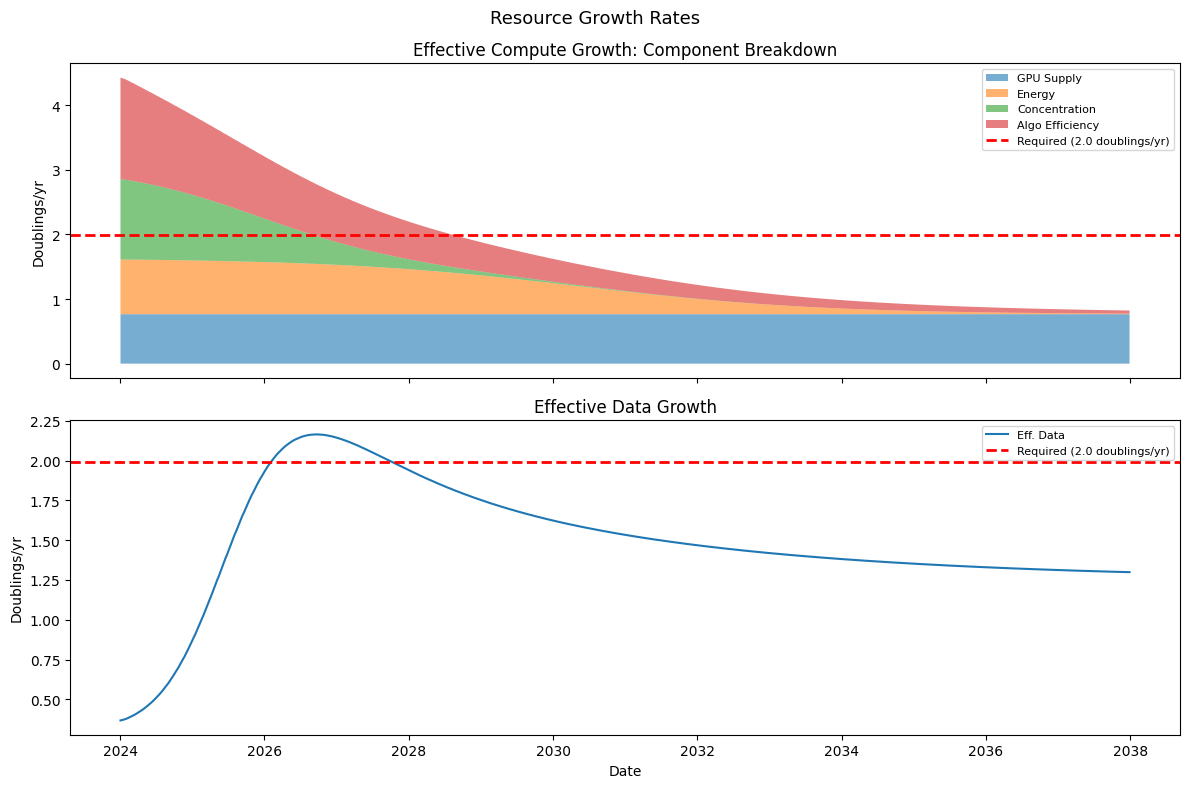

In [4]:
# Resource constraint growth rates (in doublings per year)
g_required = np.log(2) / (required_resource_doubling_months / 12.0)
LN2 = np.log(2)

t_mid_dates = [
    date.fromordinal(int(date(2024, 1, 1).toordinal() + t * 365.25))
    for t in rates["t_mid"]
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: stacked area of compute components
components = [
    ("gpu", "GPU Supply"),
    ("energy", "Energy"),
    ("concentration", "Concentration"),
    ("algo", "Algo Efficiency"),
]
bottoms = np.zeros(len(rates["gpu"]))
for key, label in components:
    vals = np.maximum(rates[key] / LN2, 0)
    ax1.fill_between(t_mid_dates, bottoms, bottoms + vals, alpha=0.6, label=label)
    bottoms = bottoms + vals

ax1.axhline(
    y=g_required / LN2, color="r", linestyle="--", lw=2,
    label=f"Required ({g_required / LN2:.1f} doublings/yr)",
)
ax1.set_ylabel("Doublings/yr")
ax1.set_title("Effective Compute Growth: Component Breakdown")
ax1.legend(fontsize=8)

# Bottom: effective data growth rate
ax2.plot(t_mid_dates, rates["data"] / LN2, lw=1.5, label="Eff. Data")
ax2.axhline(
    y=g_required / LN2, color="r", linestyle="--", lw=2,
    label=f"Required ({g_required / LN2:.1f} doublings/yr)",
)
ax2.set_ylabel("Doublings/yr")
ax2.set_xlabel("Date")
ax2.set_title("Effective Data Growth")
ax2.legend(fontsize=8)

plt.suptitle("Resource Growth Rates", fontsize=13)
plt.tight_layout()
plt.show()

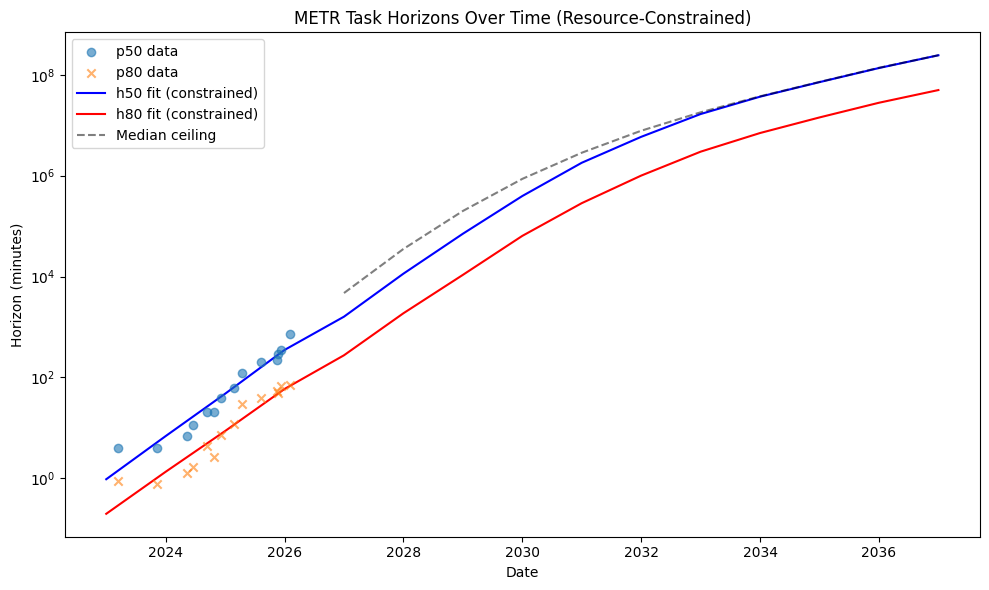

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Data points
ax.scatter(df["release_date"], df["p50_horizon"], alpha=0.6, label="p50 data", zorder=3)
ax.scatter(df["release_date"], df["p80_horizon"], alpha=0.6, label="p80 data", zorder=3, marker="x")

# Sample horizons with time-varying ceiling per year
h50_samples = np.zeros((len(t_months), n_samples))
h80_samples = np.zeros((len(t_months), n_samples))
for i, t in enumerate(t_months):
    ceiling = ceiling_matrix[i, :]
    h50_samples[i], h80_samples[i] = fit.sample_horizons(t, n=n_samples, ceiling=ceiling)

h50_median = np.median(h50_samples, axis=1)
h80_median = np.median(h80_samples, axis=1)

ax.plot(dates, h50_median, "b-", label="h50 fit (constrained)")
ax.plot(dates, h80_median, "r-", label="h80 fit (constrained)")

# Show median ceiling trajectory (only where ceiling is real, not sentinel)
ceil_median = np.median(ceiling_matrix, axis=1)
mask = ceil_median < 1e9
if np.any(mask):
    ceil_dates = [d for d, m in zip(dates, mask) if m]
    ceil_vals = ceil_median[mask]
    ax.plot(ceil_dates, ceil_vals, "k--", alpha=0.5, label="Median ceiling")

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Horizon (minutes)")
ax.set_title("METR Task Horizons Over Time (Resource-Constrained)")
ax.legend()
plt.tight_layout()
plt.show()

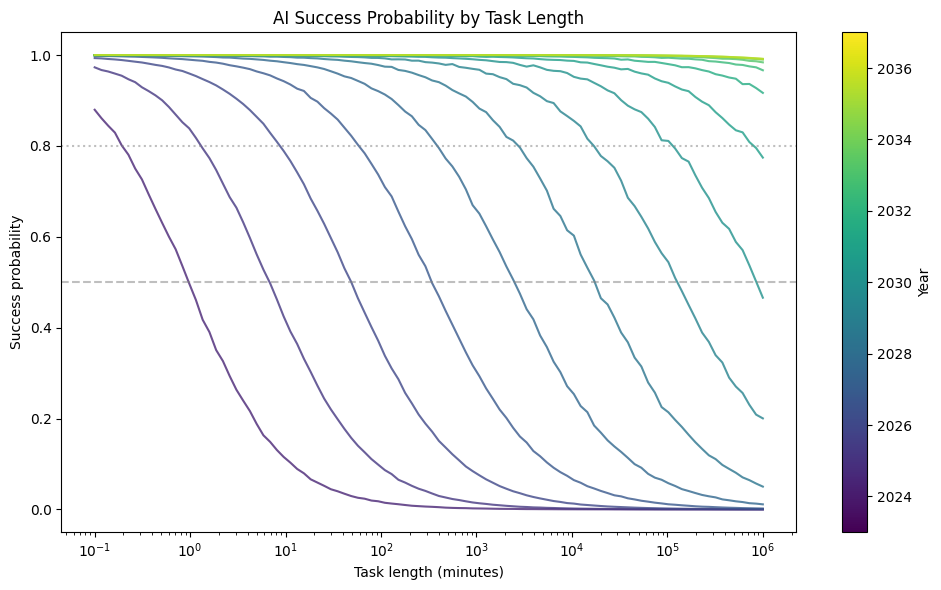

In [6]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 6))

task_range_min = np.logspace(-1, 6, 100)  # 0.1 min to 10,000 min

# Color gradient from light to dark
colors = cm.viridis(np.linspace(0.1, 0.9, len(years)))

for i, year in enumerate(years):
    d = date(year, 1, 1)
    t = (d - fit.base_date).days / 30.44

    # Median success probability at each task length
    probs = np.array(
        [
            np.median(fit.success_probability(task, t, n=n_samples, ceiling=ceiling))
            for task in task_range_min
        ]
    )
    ax.plot(task_range_min, probs, color=colors[i], alpha=0.8)

ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50%")
ax.axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="80%")
ax.set_xscale("log")
ax.set_xlabel("Task length (minutes)")
ax.set_ylabel("Success probability")
ax.set_title("AI Success Probability by Task Length")

# Add colorbar for years
sm = cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(min(years), max(years)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Year")

plt.tight_layout()
plt.show()

In [7]:
sw_task_distribution = sq.lognorm(10, 480)  # 90% CI: 10 min to 8 hr

n_tasks = 100000
task_durations = sw_task_distribution @ n_tasks
total_volume = np.sum(task_durations)

rows = []
for idx_t, (d, t) in enumerate(zip(dates, t_months)):
    ceiling = ceiling_matrix[idx_t, :]
    h50, h80 = fit.sample_horizons(t, n=n_samples, ceiling=ceiling)
    k = np.log(0.25) / np.log(h80 / h50)

    for i in range(n_samples):
        log_ratio = k[i] * np.log(task_durations / h50[i])
        log_ratio = np.clip(log_ratio, -50, 50)
        probs = 1 / (1 + np.exp(log_ratio))
        automated_volume = np.sum(task_durations * probs)
        frac_automated = automated_volume / total_volume
        speedup = 1 / (1 - frac_automated)

        rows.append({
            "date": d,
            "h50": h50[i],
            "h80": h80[i],
            "k": k[i],
            "frac_automated": frac_automated,
            "speedup": speedup,
        })

results = pd.DataFrame(rows)

summary = (
    results.groupby("date")
    .agg(
        h50_median=("h50", "median"),
        h80_median=("h80", "median"),
        k_median=("k", "median"),
        frac_automated_median=("frac_automated", "median"),
        speedup_median=("speedup", "median"),
        speedup_p5=("speedup", lambda x: np.percentile(x, 5)),
        speedup_p95=("speedup", lambda x: np.percentile(x, 95)),
    )
    .reset_index()
)

print(summary.to_string(index=False))

      date   h50_median   h80_median  k_median  frac_automated_median  speedup_median   speedup_p5   speedup_p95
2023-01-01 9.256626e-01 1.917955e-01  0.882389               0.010864        1.010984     1.004800      1.022170
2024-01-01 6.679438e+00 1.317423e+00  0.848383               0.060512        1.064409     1.044925      1.089126
2025-01-01 4.840007e+01 8.689404e+00  0.812516               0.231506        1.301247     1.257336      1.354196
2026-01-01 3.476630e+02 5.783979e+01  0.776681               0.537671        2.162963     1.947185      2.425511
2027-01-01 1.599432e+03 2.732350e+02  0.785383               0.763983        4.236983     3.448973      5.260466
2028-01-01 1.134004e+04 1.883969e+03  0.774286               0.926149       13.540759     8.422678     22.083993
2029-01-01 7.300154e+04 1.153803e+04  0.755036               0.978925       47.448929    18.567802    111.506183
2030-01-01 4.045791e+05 6.493590e+04  0.765148               0.994174      171.658269    44.7953

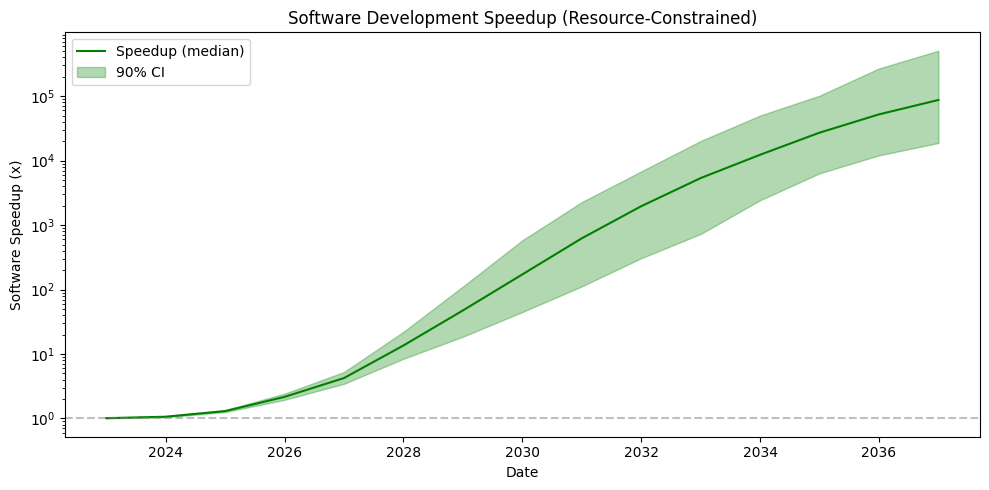

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(summary["date"], summary["speedup_median"], "g-", label="Speedup (median)")
ax.fill_between(
    summary["date"],
    summary["speedup_p5"],
    summary["speedup_p95"],
    alpha=0.3,
    color="green",
    label="90% CI",
)
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Software Speedup (x)")
ax.set_title("Software Development Speedup (Resource-Constrained)")
ax.legend(loc="upper left")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
from physical import (
    HardwareCapability,
    PhysicalHorizon,
    sample_physical_speedup,
)

ph = PhysicalHorizon()
hw = HardwareCapability()

# Use median software speedup from METR model at each time point
sw_speedup_by_year = dict(zip(summary["date"], summary["speedup_median"]))

# Physical task duration distributions (literature-anchored)
phys_tasks_structured = sq.lognorm(5, 240) @ n_tasks  # 5 min to 4 hr
phys_tasks_unstructured = sq.lognorm(5, 480) @ n_tasks  # 5 min to 8 hr

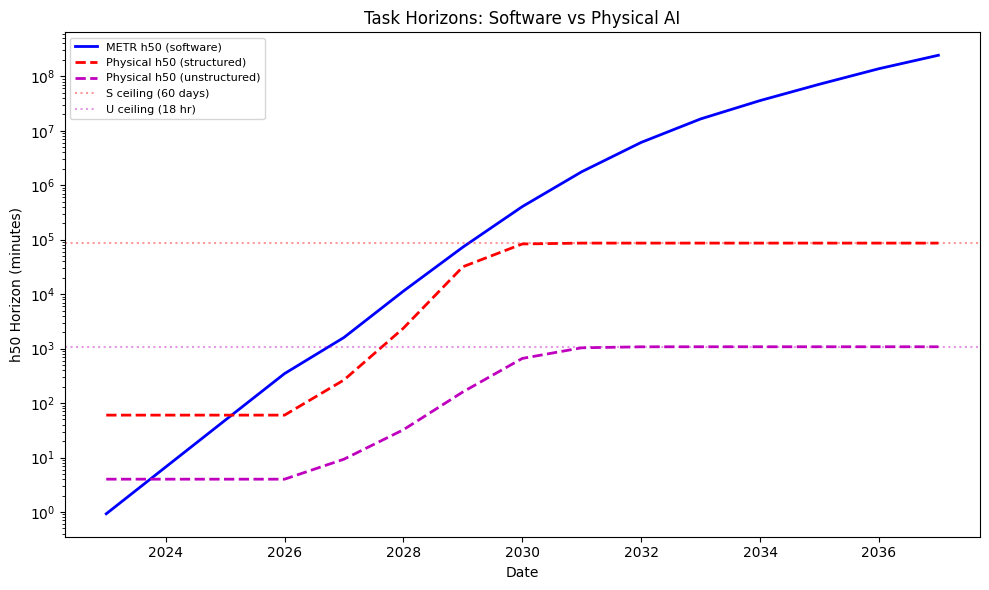

In [10]:
# Physical horizon projections alongside METR
fig, ax = plt.subplots(figsize=(10, 6))

# Base date for physical model is Jan 2026
phys_base = date(2026, 1, 1)
phys_t = [(d - phys_base).days / 30.44 for d in dates]

# METR h50 (from earlier fit)
ax.plot(dates, summary["h50_median"], "b-", linewidth=2, label="METR h50 (software)")

# Physical h50 by environment type, using median SW speedup
h50_structured = []
h50_unstructured = []
for d, t_p in zip(dates, phys_t):
    sw = sw_speedup_by_year.get(d, 1.0)
    t_phys = max(t_p, 0)
    h50_structured.append(ph.horizon_at(t_phys, "structured", sw))
    h50_unstructured.append(ph.horizon_at(t_phys, "unstructured", sw))

ax.plot(dates, h50_structured, "r--", linewidth=2, label="Physical h50 (structured)")
ax.plot(dates, h50_unstructured, "m--", linewidth=2, label="Physical h50 (unstructured)")

# Show ceilings
ax.axhline(
    y=ph.ceiling_structured, color="r", linestyle=":",
    alpha=0.4, label=f"S ceiling ({ph.ceiling_structured / 60 / 24:.0f} days)",
)
ax.axhline(
    y=ph.ceiling_unstructured, color="m", linestyle=":",
    alpha=0.4, label=f"U ceiling ({ph.ceiling_unstructured / 60:.0f} hr)",
)

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("h50 Horizon (minutes)")
ax.set_title("Task Horizons: Software vs Physical AI")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

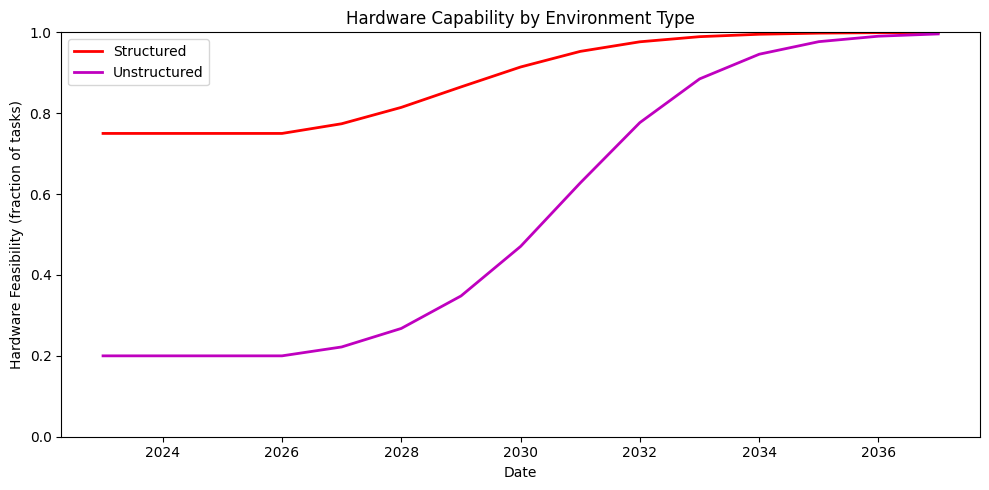

In [11]:
# Hardware capability evolution
fig, ax = plt.subplots(figsize=(10, 5))

hw_structured = []
hw_unstructured = []
for d, t_p in zip(dates, phys_t):
    sw = sw_speedup_by_year.get(d, 1.0)
    t_phys = max(t_p, 0)
    hw_structured.append(hw.feasibility_at(t_phys, "structured", sw))
    hw_unstructured.append(hw.feasibility_at(t_phys, "unstructured", sw))

ax.plot(dates, hw_structured, "r-", linewidth=2, label="Structured")
ax.plot(dates, hw_unstructured, "m-", linewidth=2, label="Unstructured")
ax.set_ylim(0, 1)
ax.set_xlabel("Date")
ax.set_ylabel("Hardware Feasibility (fraction of tasks)")
ax.set_title("Hardware Capability by Environment Type")
ax.legend()
plt.tight_layout()
plt.show()

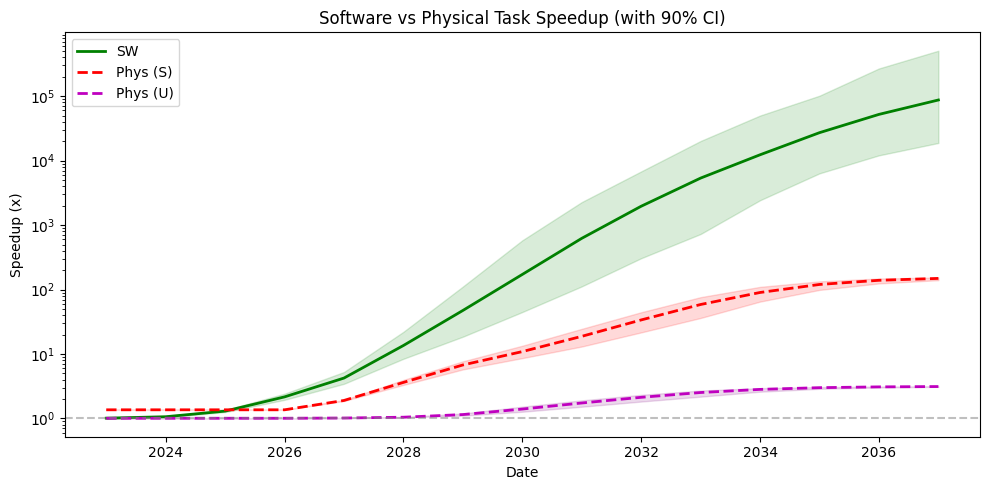

  Year          SW          Phys-S          Phys-U    HW-S    HW-U
  2023        1.01   1.36 [ 1.4-  1.4]   1.01 [ 1.0-  1.0]    0.75    0.20
  2024        1.06   1.36 [ 1.4-  1.4]   1.01 [ 1.0-  1.0]    0.75    0.20
  2025        1.30   1.36 [ 1.4-  1.4]   1.01 [ 1.0-  1.0]    0.75    0.20
  2026        2.16   1.36 [ 1.4-  1.4]   1.01 [ 1.0-  1.0]    0.75    0.20
  2027        4.24   1.90 [ 1.9-  1.9]   1.02 [ 1.0-  1.0]    0.77    0.22
  2028       13.54   3.62 [ 3.3-  4.0]   1.05 [ 1.0-  1.1]    0.81    0.27
  2029       47.45   6.77 [ 5.8-  7.7]   1.15 [ 1.1-  1.2]    0.87    0.35
  2030      171.66  10.91 [ 8.6- 13.4]   1.40 [ 1.3-  1.5]    0.91    0.47
  2031      622.77  18.79 [13.1- 24.6]   1.74 [ 1.5-  1.9]    0.95    0.63
  2032     1959.38  33.76 [21.6- 44.4]   2.13 [ 1.8-  2.3]    0.98    0.78
  2033     5366.08  58.68 [36.2- 76.3]   2.53 [ 2.2-  2.7]    0.99    0.88
  2034    12329.71  90.09 [65.0-110.1]   2.83 [ 2.6-  3.0]    1.00    0.95
  2035    27145.55  119.96 [98.7-

In [12]:
# Combined speedup with Monte Carlo: use SW speedup samples per year
phys_summary_rows = []
for d, t_p in zip(dates, phys_t):
    t_phys = max(t_p, 0)
    # Get SW speedup samples for this year from the results DataFrame
    sw_samples = results[results["date"] == d]["speedup"].values
    if len(sw_samples) == 0:
        sw_samples = np.array([1.0])

    for env, tasks in [("structured", phys_tasks_structured),
                       ("unstructured", phys_tasks_unstructured)]:
        ps = sample_physical_speedup(t_phys, sw_samples, env, tasks, ph, hw)
        phys_summary_rows.append({
            "date": d,
            "env": env,
            "median": np.median(ps),
            "p5": np.percentile(ps, 5),
            "p95": np.percentile(ps, 95),
        })

phys_summary = pd.DataFrame(phys_summary_rows)
ps_s = phys_summary[phys_summary["env"] == "structured"]
ps_u = phys_summary[phys_summary["env"] == "unstructured"]

fig, ax = plt.subplots(figsize=(10, 5))

# Software speedup
ax.plot(summary["date"], summary["speedup_median"], "g-", lw=2, label="SW")
ax.fill_between(
    summary["date"], summary["speedup_p5"], summary["speedup_p95"],
    alpha=0.15, color="green",
)

# Physical structured
ax.plot(ps_s["date"].values, ps_s["median"].values, "r--", lw=2, label="Phys (S)")
ax.fill_between(
    ps_s["date"].values, ps_s["p5"].values, ps_s["p95"].values,
    alpha=0.15, color="red",
)

# Physical unstructured
ax.plot(ps_u["date"].values, ps_u["median"].values, "m--", lw=2, label="Phys (U)")
ax.fill_between(
    ps_u["date"].values, ps_u["p5"].values, ps_u["p95"].values,
    alpha=0.15, color="purple",
)

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Speedup (x)")
ax.set_title("Software vs Physical Task Speedup (with 90% CI)")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# Summary table
print(
    f"{'Year':>6}  {'SW':>10}  {'Phys-S':>14}  {'Phys-U':>14}"
    f"  {'HW-S':>6}  {'HW-U':>6}"
)
for i, d in enumerate(dates):
    sw_med = summary[summary["date"] == d]["speedup_median"].values[0]
    s_row = ps_s[ps_s["date"] == d].iloc[0]
    u_row = ps_u[ps_u["date"] == d].iloc[0]
    hs = hw.feasibility_at(max(phys_t[i], 0), "structured", sw_med)
    hu = hw.feasibility_at(max(phys_t[i], 0), "unstructured", sw_med)
    print(
        f"{d.year:>6}  {sw_med:>10.2f}"
        f"  {s_row['median']:>5.2f}"
        f" [{s_row['p5']:>4.1f}-{s_row['p95']:>5.1f}]"
        f"  {u_row['median']:>5.2f}"
        f" [{u_row['p5']:>4.1f}-{u_row['p95']:>5.1f}]"
        f"  {hs:>6.2f}  {hu:>6.2f}"
    )